Libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


Edge Detection


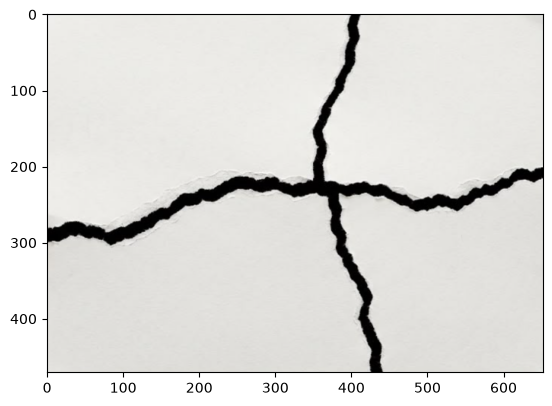

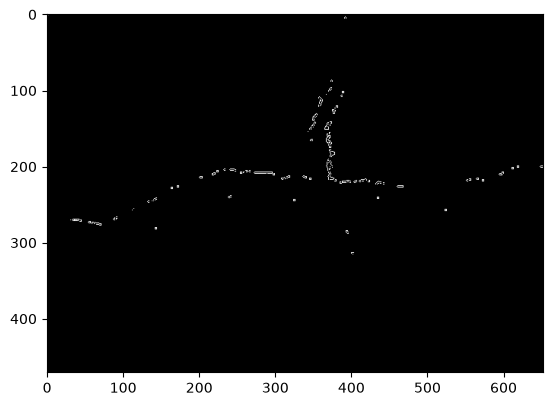

In [27]:
image_path = r'D:\PythonProject1\Intern\Images\img23.png'
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)
_, thresh = cv2.threshold(gray_image, 240, 245, cv2.THRESH_BINARY_INV)
canny = cv2.Canny(thresh,50,150)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(canny, cmap='gray')
plt.show()

Seperate Each Torn Fragment using Contours

In [28]:
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
contour_img = image.copy()
cv2.drawContours(contour_img, valid_contours, -1, (0, 255, 0), 3)


array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]]

In [29]:
isolated_pieces_list = []  
count=0
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad =0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    rgb_piece = cv2.cvtColor(isolated_piece, cv2.COLOR_BGR2RGB)
    isolated_pieces_list.append(rgb_piece)
    count += 1
    # plt.imshow(rgb_piece)
    # plt.show()

In [30]:
img = isolated_pieces_list[0]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
y, x = np.where(thresh == 255)
highest = np.argmax(x)
peak_x = x[highest]
peak_y = y[highest]
output_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
cv2.circle(output_img, (peak_x, peak_y), 0, (0,0,255), -1)
# plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
# plt.show()
# print(peak_y)
# print(peak_x)

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[229, 228, 224],
        [229, 228, 224],
        [228, 227, 223],
        ...,
        [211, 211, 211],
        [218, 218, 218],
        [  0,   0,   0]],

       [[230, 229, 225],
        [231, 230, 226],
        [230, 229, 225],
        ...,
        [213, 213, 213],
        [218, 218, 218],
        [  0,   0,   0]],

       [[232, 231, 227],
        [233, 231, 228],
        [231, 230, 226],
        ...,
        [216, 216, 216],
        [220, 220, 220],
        [  0,   0,   0]]

Add padding using peak

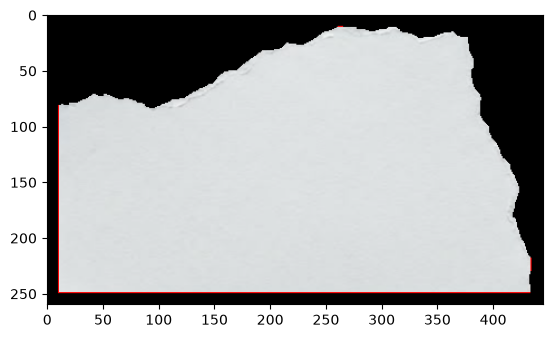

In [31]:
bottom = np.max(y)  
right = np.max(x)  
top= np.min(y) 
left = np.min(x)  
padding_color=[0,0,0]
output= cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
output = cv2.copyMakeBorder(output,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)

bottom += 10
right += 10
top += 10
left += 10
y1 = x[y == (bottom-10)]+10
for peak_y in y1:
    cv2.circle(output, (peak_y, bottom), 0, (0, 0, 255), -1)
    # print(peak_y, bottom)

y2 = y[x == right-10]+10 
for peak_y in y2:
    cv2.circle(output, (right, peak_y), 0, (0, 0, 255), -1) 
    #print(x2,peak_y)

y3 = x[y == top-10]+10 
for peak_y in y3:
    cv2.circle(output, (peak_y, top), 0, (0, 0, 255), -1)
    #print(peak_y, x3)
y4 = y[x == left-10]+10 
for peak_y in y4:
    cv2.circle(output, (left, peak_y), 0, (0, 0, 255), -1)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()



Top :    TORN (avg: 41.89px)
Bottom : STRAIGHT (avg: 0.97px)
Left :   TORN (avg: 80.21px)
Right :  TORN (avg: 24.97px)


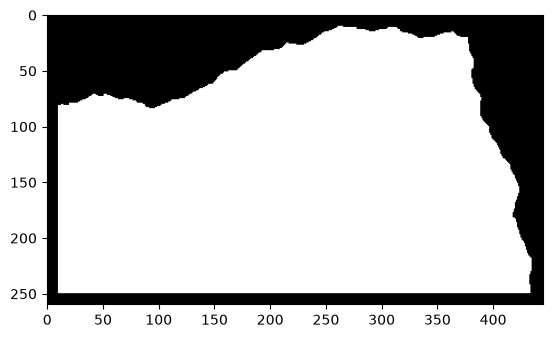

Top :    TORN (avg: 12.78px)
Bottom : TORN (avg: 55.52px)
Left :   TORN (avg: 54.92px)
Right :  STRAIGHT (avg: 0.00px)


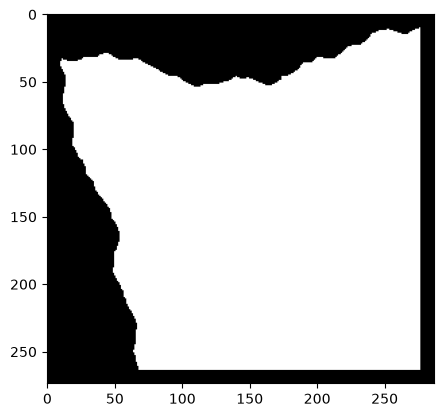

Top :    TORN (avg: 39.18px)
Bottom : TORN (avg: 12.13px)
Left :   TORN (avg: 27.49px)
Right :  TORN (avg: 30.60px)


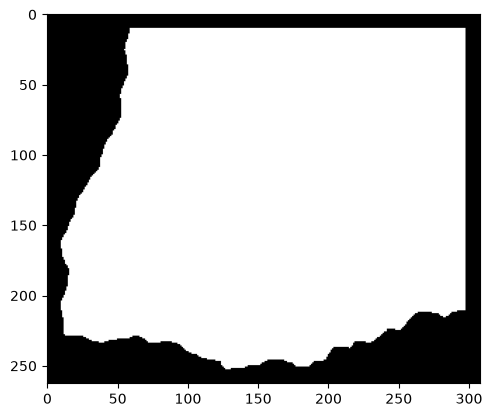

Top :    STRAIGHT (avg: 0.00px)
Bottom : TORN (avg: 55.91px)
Left :   TORN (avg: 10.14px)
Right :  TORN (avg: 93.93px)


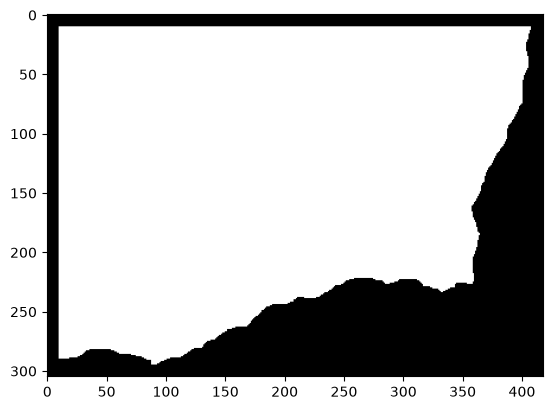

In [32]:
for i in isolated_pieces_list:
    padded_image = cv2.copyMakeBorder(i, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    points = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(points)

    tol = 1.5 

    top_deviations = []
    bottom_deviations = []

    for col in range(x, x + w):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            actual_top_edge = white_pixels[0]
            top_deviations.append(int(actual_top_edge - y))
                    
            actual_bottom_edge = white_pixels[-1]
            absolute_bottom_peak = y + h
            bottom_deviations.append(int(absolute_bottom_peak - actual_bottom_edge))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0

    top1_is_torn = std_top > tol
    bottom1_is_torn = std_bottom > tol

    print(f"Top :    {'TORN' if top1_is_torn else 'STRAIGHT'} (avg: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom1_is_torn else 'STRAIGHT'} (avg: {std_bottom:.2f}px)")


    left_avg = []
    right_avg = []

    for row in range(y, y + h):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            actual_left_edge = white_pixels[0]
            left_avg.append(int(actual_left_edge - x))
                    
            actual_right_edge = white_pixels[-1]
            absolute_right_peak = x + w
            right_avg.append(int(absolute_right_peak - actual_right_edge))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0

    left1_is_torn = std_left > tol
    right1_is_torn = std_right > tol

    print(f"Left :   {'TORN' if left1_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right1_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    plt.imshow(thresh, cmap='gray')
    plt.show()

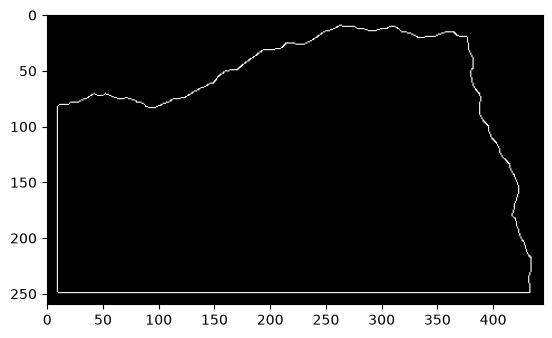

[(9, 82), (10, 81), (11, 80), (12, 80), (13, 80), (14, 80), (15, 80), (16, 80), (17, 80), (18, 80), (19, 80), (20, 79), (21, 78), (22, 78), (23, 78), (24, 78), (25, 78), (26, 78), (27, 78), (28, 78), (29, 77), (30, 77), (31, 76), (32, 76), (33, 75), (34, 75), (35, 75), (36, 74), (37, 73), (38, 73), (39, 72), (40, 71), (41, 71), (42, 70), (43, 71), (44, 71), (45, 72), (46, 72), (47, 72), (48, 72), (49, 72), (50, 72), (51, 71), (52, 70), (53, 71), (54, 71), (55, 71), (56, 72), (57, 72), (58, 73), (59, 73), (60, 74), (61, 74), (62, 74), (63, 75), (64, 75), (65, 75), (66, 75), (67, 75), (68, 75), (69, 75), (70, 74), (71, 74), (72, 74), (73, 75), (74, 75), (75, 75), (76, 76), (77, 76), (78, 76), (79, 77), (80, 77), (81, 78), (82, 78), (83, 78), (84, 78), (85, 79), (86, 79), (87, 80), (88, 81), (89, 82), (90, 82), (91, 83), (92, 83), (93, 83), (94, 83), (95, 83), (96, 83), (97, 83), (98, 82), (99, 82), (100, 81), (101, 81), (102, 80), (103, 80), (104, 79), (105, 79), (106, 79), (107, 78), (1

In [33]:
img=isolated_pieces_list[0]
img = cv2.copyMakeBorder(img,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)
_, img = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
a1=cv2.Canny(img,150,150)
y_arr, x_arr = np.where(a1 == 255)

left = np.min(x_arr)
right = np.max(x_arr)
b11= []
for col_x in range(left, right + 1):
    pixels_in_col = y_arr[x_arr == col_x]
    
    if len(pixels_in_col) > 0:
        top_y = np.min(pixels_in_col)
        
        b11.append((int(col_x), int(top_y)))
plt.imshow(cv2.cvtColor(a1, cv2.COLOR_BGR2RGB))
plt.show()
a2 = cv2.copyMakeBorder(thresh,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)
g1= 5
b1=(left , top - g1)
b2=(right , bottom + g1)

cv2.rectangle(a2, b1, b2, (255, 255, 255), 1)
y_arr, x_arr = np.where(a2 == 255)

left = np.min(x_arr)
right = np.max(x_arr)
b22 = []
for col_x in range(left, right + 1):
    pixels_in_col = y_arr[x_arr == col_x]
    
    if len(pixels_in_col) > 0:
        top_y = np.min(pixels_in_col)
        
        b22.append((int(col_x), int(top_y)))
distances = [int(y11) - int(y22) for (_, y11), (_, y22) in zip(b11, b22)]

print(b11)
print(b22)
print(distances)
# plt.imshow(cv2.cvtColor(a2, cv2.COLOR_BGR2RGB))
# plt.show()


Top :    TORN (avg: 41.89px)
Bottom : STRAIGHT (avg: 0.97px)
Left :   TORN (avg: 80.21px)
Right :  TORN (avg: 24.97px)


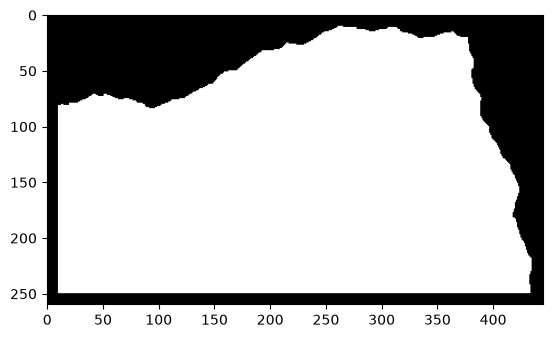

Top :    TORN (avg: 12.78px)
Bottom : TORN (avg: 55.52px)
Left :   TORN (avg: 54.92px)
Right :  STRAIGHT (avg: 0.00px)


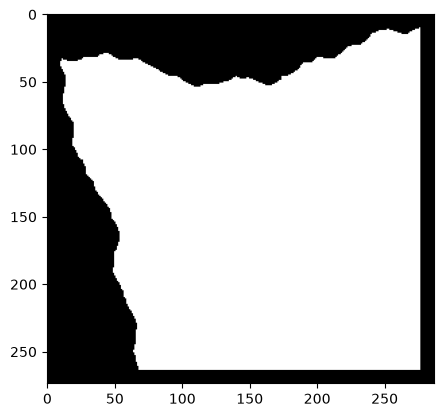

Top :    TORN (avg: 39.18px)
Bottom : TORN (avg: 12.13px)
Left :   TORN (avg: 27.49px)
Right :  TORN (avg: 30.60px)


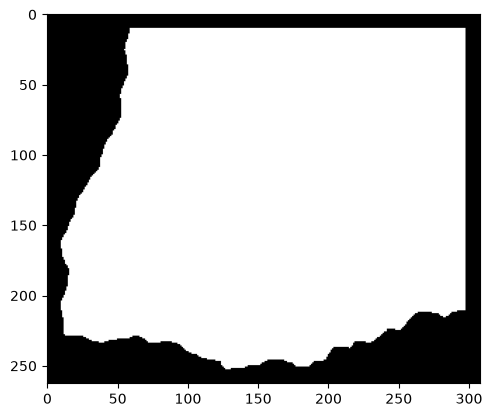

Top :    STRAIGHT (avg: 0.00px)
Bottom : TORN (avg: 55.91px)
Left :   TORN (avg: 10.14px)
Right :  TORN (avg: 93.93px)


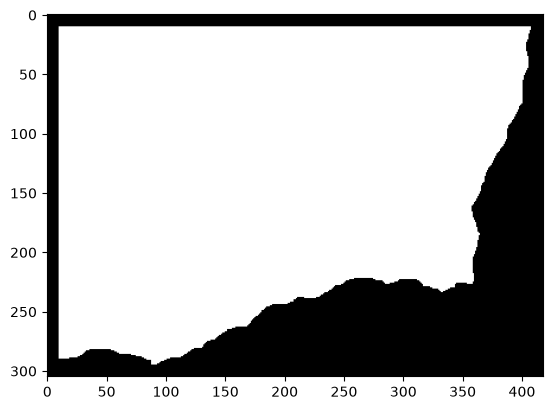

In [34]:
for i in isolated_pieces_list:
    padded_image = cv2.copyMakeBorder(i, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    points = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(points)

    tol = 1.5 

    top_deviations = []
    bottom_deviations = []

    for col in range(x, x + w):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            actual_top_edge = white_pixels[0]
            top_deviations.append(int(actual_top_edge - y))
                    
            actual_bottom_edge = white_pixels[-1]
            absolute_bottom_peak = y + h
            bottom_deviations.append(int(absolute_bottom_peak - actual_bottom_edge))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0

    top1_is_torn = std_top > tol
    bottom1_is_torn = std_bottom > tol

    print(f"Top :    {'TORN' if top1_is_torn else 'STRAIGHT'} (avg: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom1_is_torn else 'STRAIGHT'} (avg: {std_bottom:.2f}px)")


    left_avg = []
    right_avg = []

    for row in range(y, y + h):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            actual_left_edge = white_pixels[0]
            left_avg.append(int(actual_left_edge - x))
                    
            actual_right_edge = white_pixels[-1]
            absolute_right_peak = x + w
            right_avg.append(int(absolute_right_peak - actual_right_edge))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0

    left1_is_torn = std_left > tol
    right1_is_torn = std_right > tol

    print(f"Left :   {'TORN' if left1_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right1_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    plt.imshow(thresh, cmap='gray')
    plt.show()

In [35]:
topp,bottomm,rightt,leftt=[],[],[],[]
pp=[]


Top :    TORN (variance: 41.89px)
Bottom : STRAIGHT (variance: 0.97px)
Left :   TORN (avg: 80.21px)
Right :  TORN (avg: 24.97px)
TOP Distances[76, 75, 75, 75, 75, 75, 75, 75, 75, 75, 74, 73, 73, 73, 73, 73, 73, 73, 73, 72, 72, 71, 71, 70, 70, 70, 69, 68, 68, 67, 66, 66, 65, 66, 66, 67, 67, 67, 67, 67, 67, 66, 65, 66, 66, 66, 67, 67, 68, 68, 69, 69, 69, 70, 70, 70, 70, 70, 70, 70, 69, 69, 69, 70, 70, 70, 71, 71, 71, 72, 72, 73, 73, 73, 73, 74, 74, 75, 76, 77, 77, 78, 78, 78, 78, 78, 78, 78, 77, 77, 76, 76, 75, 75, 74, 74, 74, 73, 73, 73, 72, 71, 71, 70, 70, 70, 70, 70, 70, 70, 69, 69, 69, 69, 68, 68, 67, 66, 66, 65, 64, 64, 63, 63, 63, 62, 61, 61, 60, 60, 60, 59, 59, 58, 57, 57, 56, 56, 56, 55, 54, 53, 52, 50, 49, 48, 48, 47, 46, 46, 45, 45, 45, 45, 44, 44, 44, 44, 44, 44, 44, 43, 42, 41, 40, 39, 39, 38, 37, 37, 36, 35, 34, 34, 33, 32, 32, 31, 30, 29, 29, 28, 27, 27, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 25, 25, 25, 25, 25, 24, 23, 22, 21, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 2

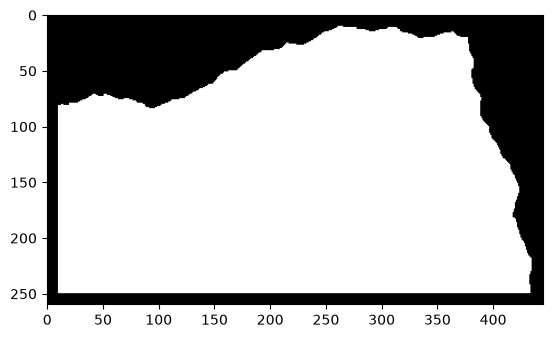

Top :    TORN (variance: 12.78px)
Bottom : TORN (variance: 55.52px)
Left :   TORN (avg: 54.92px)
Right :  STRAIGHT (avg: 0.00px)
TOP Distances[28, 28, 28, 28, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 28, 28, 27, 27, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 25, 25, 24, 24, 24, 23, 23, 24, 24, 25, 25, 26, 27, 27, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 27, 27, 28, 28, 29, 29, 30, 31, 31, 32, 32, 33, 33, 34, 34, 35, 35, 36, 36, 37, 38, 38, 39, 39, 40, 40, 40, 40, 40, 40, 40, 41, 41, 42, 42, 43, 44, 45, 45, 46, 46, 47, 47, 48, 48, 48, 48, 48, 48, 48, 47, 47, 46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 45, 45, 45, 44, 44, 44, 44, 43, 42, 42, 41, 41, 41, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 43, 43, 44, 44, 45, 45, 45, 46, 46, 47, 47, 47, 47, 47, 47, 47, 46, 46, 45, 44, 44, 42, 41, 40, 40, 40, 40, 40, 39, 39, 38, 37, 37, 36, 35, 34, 32, 31, 31, 30, 30, 30, 30, 30, 30, 29, 28, 27, 27, 26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 25, 25, 24, 23, 22, 21, 20, 19, 19, 1

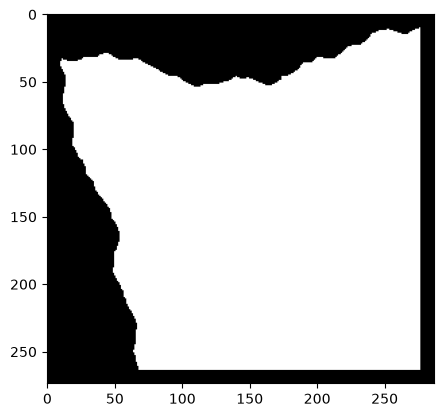

Top :    TORN (variance: 39.18px)
Bottom : TORN (variance: 12.13px)
Left :   TORN (avg: 27.49px)
Right :  TORN (avg: 30.60px)
TOP Distances[155, 153, 151, 150, 147, 144, 142, 140, 139, 134, 129, 127, 125, 123, 122, 121, 119, 117, 116, 114, 112, 110, 109, 108, 107, 106, 105, 98, 96, 92, 89, 87, 85, 83, 82, 81, 79, 77, 75, 73, 72, 53, 49, 47, 44, 16, 14, 10, 6, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

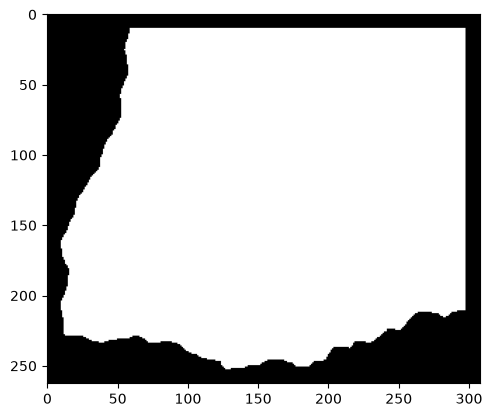

Top :    STRAIGHT (variance: 0.00px)
Bottom : TORN (variance: 55.91px)
Left :   TORN (avg: 10.14px)
Right :  TORN (avg: 93.93px)
BOTTOM Distances[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 12, 12, 13, 13, 14, 15, 16, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 16, 16, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 12, 12, 12, 12, 12, 11, 11, 10, 10, 9, 9, 9, 9, 6, 5, 5, 5, 5, 5, 5, 6, 6, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 13, 14, 14, 15, 16, 16, 17, 18, 18, 19, 19, 19, 19, 19, 19, 19, 21, 22, 23, 24, 25, 25, 25, 26, 26, 26, 26, 27, 28, 29, 30, 30, 31, 32, 32, 33, 34, 35, 35, 35, 35, 36, 36, 36, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 38, 39, 41, 42, 43, 44, 45, 46, 46, 47, 48, 50, 51, 51, 52, 53, 54, 54, 54, 55, 55, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 57, 57, 58, 58, 59, 60, 60, 61, 62, 62, 62, 62, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 6

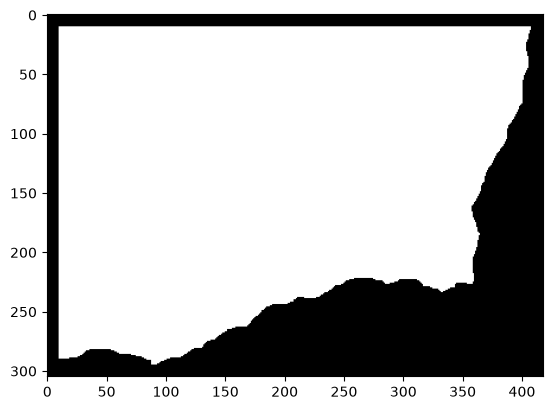

In [36]:
image_path = r'D:\PythonProject1\Intern\Images\img23.png'
image = cv2.imread(image_path)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)

_, thresh_init = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh_init, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

isolated_pieces_list = []  
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    isolated_pieces_list.append(isolated_piece)

for  current_piece in isolated_pieces_list:
    padded_image = cv2.copyMakeBorder(current_piece, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    points = cv2.findNonZero(thresh)
    
    x_box, y_box, w_box, h_box = cv2.boundingRect(points)

    tol = 1.5 
    top_deviations, bottom_deviations = [], []

    for col in range(x_box, x_box + w_box):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            top_deviations.append(int(white_pixels[0] - y_box))
            bottom_deviations.append(int((y_box + h_box) - white_pixels[-1]))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0
    
    top_is_torn = std_top > tol
    bottom_is_torn = std_bottom > tol
    
    print(f"Top :    {'TORN' if top_is_torn else 'STRAIGHT'} (variance: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom_is_torn else 'STRAIGHT'} (variance: {std_bottom:.2f}px)")

    left_avg, right_avg = [], []
    for row in range(y_box, y_box + h_box):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            left_avg.append(int(white_pixels[0] - x_box))
            right_avg.append(int((x_box + w_box) - white_pixels[-1]))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0
    
    left_is_torn = std_left > tol
    right_is_torn = std_right > tol
    
    print(f"Left :   {'TORN' if left_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    a1 = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(a1 == 255)
    
    y_pixels, x_pixels = np.where(thresh == 255)
    min_y, max_y = np.min(y_pixels), np.max(y_pixels)
    min_x, max_x = np.min(x_pixels), np.max(x_pixels)
    
    g1 = 5  
    any_torn = False

    if top_is_torn:
        any_torn = True
        b11_top = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_top.append((int(col_x), int(np.min(pixels_in_col))))
        
        top_ref_y = int(min_y - g1)
        distances_top = [abs(int(y11) - top_ref_y) for _, y11 in b11_top]
        print(f"TOP Distances{distances_top}")

        topp.append(distances_top)

        
    else:
        topp.append(np.nan)

    if bottom_is_torn:
        any_torn = True
        b11_bottom = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_bottom.append((int(col_x), int(np.max(pixels_in_col))))
        
        bottom_ref_y = int(max_y + g1)
        distances_bottom = [abs(int(y11) - bottom_ref_y) for _, y11 in b11_bottom]
        print(f"BOTTOM Distances{distances_bottom}")
        
        bottomm.append(distances_bottom)
    else:
        bottomm.append(np.nan)

    if left_is_torn:
        any_torn = True
        b11_left = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_left.append((int(row_y), int(np.min(pixels_in_row))))
        
        left_ref_x = int(min_x - g1)
        distances_left = [abs(int(x11) - left_ref_x) for _, x11 in b11_left]
        print(f"LEFT Distances {distances_left}")
       
        leftt.append(distances_left)
    else:
        leftt.append(np.nan)

    if right_is_torn:
        any_torn = True
        b11_right = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_right.append((int(row_y), int(np.max(pixels_in_row))))
        
        right_ref_x = int(max_x + g1)
        distances_right = [abs(int(x11) - right_ref_x) for _, x11 in b11_right]
        
        print(f"RIGHT Distances{distances_right}")
      
        rightt.append(distances_right)
        

    else:
        rightt.append(np.nan)
    pp.append(thresh)
    plt.imshow(thresh, cmap='gray')
    plt.show()




In [37]:
side1 = rightt[0]
side2 = leftt[1]
print(side1)
print(side2)
th = 0.82
tr = 12

edge1 = np.array(side1 if len(side1) > 2*tr else side1, dtype=float)
edge2 = np.array(side2 if len(side2) > 2*tr else side2, dtype=float)

x1 = np.arange(len(edge1))
slope1, intercept1 = np.polyfit(x1, edge1, 1)
detrended1 = edge1 - (slope1 * x1 + intercept1)
roughness1 = np.std(detrended1)

x2 = np.arange(len(edge2))
slope2, intercept2 = np.polyfit(x2, edge2, 1)
detrended2 = edge2 - (slope2 * x2 + intercept2)
roughness2 = np.std(detrended2)

if roughness1 < 1.2 or roughness2 < 1.2:
    print("NOT MATCHED ")
  

else:
    norm1 = (edge1 - np.min(edge1)) / (np.max(edge1) - np.min(edge1) + 1e-6)
    norm2 = (edge2 - np.min(edge2)) / (np.max(edge2) - np.min(edge2) + 1e-6)

    if len(norm1) < len(norm2):
        shorter, longer = norm1, norm2
        is1_shorter = True
    else:
        shorter, longer = norm2, norm1
        is1_shorter = False
        
    s_len, l_len = len(shorter), len(longer)

    best_score = 0.0
    best_offset = 0

    for direction in ["Forward", "Reversed"]:
        test_shorter = shorter if direction == "Forward" else shorter[::-1]
        
        for offset in range(l_len - s_len + 1):
            segment = longer[offset:offset + s_len]
            
            dist_direct = np.mean(np.abs(test_shorter - segment))
            score_direct = 1.0 - dist_direct
            
            dist_comp = np.mean(np.abs(test_shorter - (1.0 - segment)))
            score_comp = 1.0 - dist_comp
            
            if score_direct > best_score:
                best_score = score_direct
                best_offset = offset if is1_shorter else -offset
                
            if score_comp > best_score:
                best_score = score_comp
                best_offset = offset if is1_shorter else -offset

    confidence = best_score * 100

    if best_score >= th:
        print("MATCHED ")
        print(f"Confidence Score: {confidence:.2f}%")
    else:
        print("NOT MATCHED ")
        print(f"Confidence Score: {confidence:.2f}%")



[127, 125, 124, 123, 122, 74, 73, 72, 70, 63, 62, 62, 62, 62, 62, 61, 61, 61, 61, 61, 61, 61, 60, 60, 59, 59, 58, 58, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 58, 59, 59, 59, 59, 59, 59, 58, 58, 58, 58, 58, 57, 57, 57, 56, 56, 55, 54, 53, 52, 51, 51, 51, 50, 50, 50, 50, 50, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 50, 50, 49, 49, 48, 47, 46, 45, 44, 43, 43, 43, 43, 43, 43, 42, 42, 41, 41, 41, 40, 39, 38, 37, 36, 36, 35, 35, 34, 34, 33, 33, 33, 33, 32, 32, 31, 31, 30, 28, 27, 26, 25, 24, 24, 24, 24, 24, 23, 23, 22, 22, 21, 20, 20, 20, 19, 19, 18, 18, 17, 17, 17, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 18, 18, 18, 19, 19, 20, 20, 20, 20, 20, 20, 21, 21, 21, 22, 22, 22, 21, 19, 19, 19, 18, 18, 18, 18, 18, 17, 17, 16, 16, 16, 16, 15, 15, 15, 14, 14, 13, 12, 12, 11, 11, 11, 10, 10, 10, 9, 9, 9, 8, 8, 7, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6]
[269, 242, 240, 237, 235, 235, 234, 233, 232, 231, 230, 228, 222, 219, 217

Gap Removed -> dx: 370px, Perfect dy: -14px


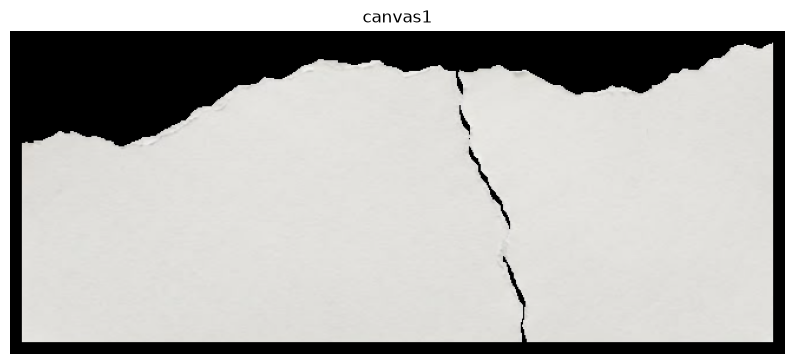

In [38]:


img2 = cv2.copyMakeBorder(isolated_pieces_list[0], 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
img3 = cv2.copyMakeBorder(isolated_pieces_list[1], 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])

gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
_, thresh2 = cv2.threshold(gray2, 15, 255, cv2.THRESH_BINARY)

gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
_, thresh3 = cv2.threshold(gray3, 15, 255, cv2.THRESH_BINARY)

y2_bottom_ref = int(np.where(thresh2 == 255)[0].max())
y3_bottom_ref = int(np.where(thresh3 == 255)[0].max())
dy = y2_bottom_ref - y3_bottom_ref

edge_map2 = cv2.Canny(thresh2, 150, 150)
y_arr2, x_arr2 = np.where(edge_map2 == 255)
y_pixels2, x_pixels2 = np.where(thresh2 == 255)
min_y2, max_y2 = np.min(y_pixels2), np.max(y_pixels2)

b2_coords = {}
for row in range(min_y2, max_y2 + 1):
    pixels_in_row = x_arr2[y_arr2 == row]
    if len(pixels_in_row) > 0:
        b2_coords[row] = np.max(pixels_in_row)

edge_map3 = cv2.Canny(thresh3, 150, 150)
y_arr3, x_arr3 = np.where(edge_map3 == 255)
y_pixels3, x_pixels3 = np.where(thresh3 == 255)
min_y3, max_y3 = np.min(y_pixels3), np.max(y_pixels3)

b3_coords = {}
for row in range(min_y3, max_y3 + 1):
    pixels_in_row = x_arr3[y_arr3 == row]
    if len(pixels_in_row) > 0:
        b3_coords[row] = np.min(pixels_in_row)

dx_offsets = []
for y3, x3 in b3_coords.items():
    corresponding_y2 = y3 + dy
    if corresponding_y2 in b2_coords:
        x2 = b2_coords[corresponding_y2]
        dx_offsets.append(x2 - x3)

dx = int(np.percentile(dx_offsets, 90))

print(f"Gap Removed -> dx: {dx}px, Perfect dy: {dy}px")

h2, w2 = img2.shape[:2]
h3, w3 = img3.shape[:2]

min_canvas_x = min(0, dx)
max_canvas_x = max(w2, w3 + dx)
min_canvas_y = min(0, dy)
max_canvas_y = max(h2, h3 + dy)

canvas_width = max_canvas_x - min_canvas_x
canvas_height = max_canvas_y - min_canvas_y

canvas1 = np.zeros((canvas_height, canvas_width, 3), dtype=np.uint8)

offset_x2 = -min_canvas_x
offset_y2 = -min_canvas_y

offset_x3 = dx - min_canvas_x
offset_y3 = dy - min_canvas_y

canvas1[offset_y2:offset_y2+h2, offset_x2:offset_x2+w2][thresh2 > 0] = img2[thresh2 > 0]
canvas1[offset_y3:offset_y3+h3, offset_x3:offset_x3+w3][thresh3 > 0] = img3[thresh3 > 0]

plt.figure(figsize=(10, 8))
plt.title("canvas1")
plt.imshow(cv2.cvtColor(canvas1, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Gap Removed -> dx: 349px, Perfect dy: 0px


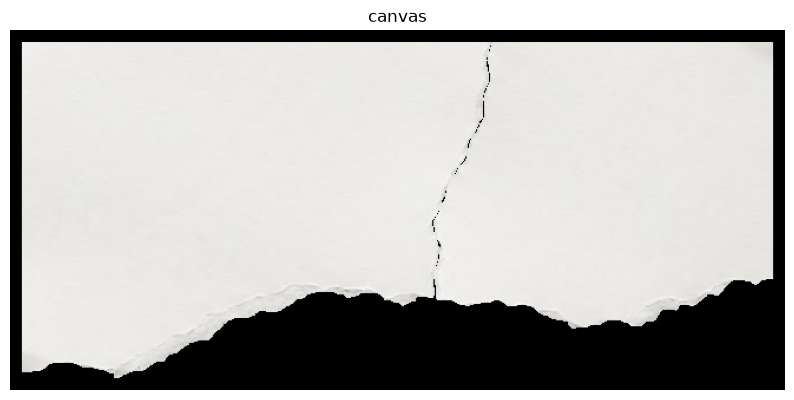

In [39]:


img2 = cv2.copyMakeBorder(isolated_pieces_list[3], 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
img3 = cv2.copyMakeBorder(isolated_pieces_list[2], 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])

gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
_, thresh2 = cv2.threshold(gray2, 15, 255, cv2.THRESH_BINARY)

gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
_, thresh3 = cv2.threshold(gray3, 15, 255, cv2.THRESH_BINARY)

y2_top_ref = int(np.where(thresh2 == 255)[0].min())
y3_top_ref = int(np.where(thresh3 == 255)[0].min())
dy = y2_top_ref - y3_top_ref

edge_map2 = cv2.Canny(thresh2, 150, 150)
y_arr2, x_arr2 = np.where(edge_map2 == 255)
y_pixels2, x_pixels2 = np.where(thresh2 == 255)
min_y2, max_y2 = np.min(y_pixels2), np.max(y_pixels2)

b2_coords = {}
for row in range(min_y2, max_y2 + 1):
    pixels_in_row = x_arr2[y_arr2 == row]
    if len(pixels_in_row) > 0:
        b2_coords[row] = np.max(pixels_in_row)

edge_map3 = cv2.Canny(thresh3, 150, 150)
y_arr3, x_arr3 = np.where(edge_map3 == 255)
y_pixels3, x_pixels3 = np.where(thresh3 == 255)
min_y3, max_y3 = np.min(y_pixels3), np.max(y_pixels3)

b3_coords = {}
for row in range(min_y3, max_y3 + 1):
    pixels_in_row = x_arr3[y_arr3 == row]
    if len(pixels_in_row) > 0:
        b3_coords[row] = np.min(pixels_in_row)

dx_offsets = []
for y3, x3 in b3_coords.items():
    corresponding_y2 = y3 + dy
    if corresponding_y2 in b2_coords:
        x2 = b2_coords[corresponding_y2]
        dx_offsets.append(x2 - x3)

dx = int(np.percentile(dx_offsets, 90))

print(f"Gap Removed -> dx: {dx}px, Perfect dy: {dy}px")

h2, w2 = img2.shape[:2]
h3, w3 = img3.shape[:2]

min_canvas_x = min(0, dx)
max_canvas_x = max(w2, w3 + dx)
min_canvas_y = min(0, dy)
max_canvas_y = max(h2, h3 + dy)

canvas_width = max_canvas_x - min_canvas_x
canvas_height = max_canvas_y - min_canvas_y

canvas = np.zeros((canvas_height, canvas_width, 3), dtype=np.uint8)

offset_x2 = -min_canvas_x
offset_y2 = -min_canvas_y

offset_x3 = dx - min_canvas_x
offset_y3 = dy - min_canvas_y

canvas[offset_y2:offset_y2+h2, offset_x2:offset_x2+w2][thresh2 > 0] = img2[thresh2 > 0]

canvas[offset_y3:offset_y3+h3, offset_x3:offset_x3+w3][thresh3 > 0] = img3[thresh3 > 0]

plt.figure(figsize=(10, 8))
plt.title(f"canvas")
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

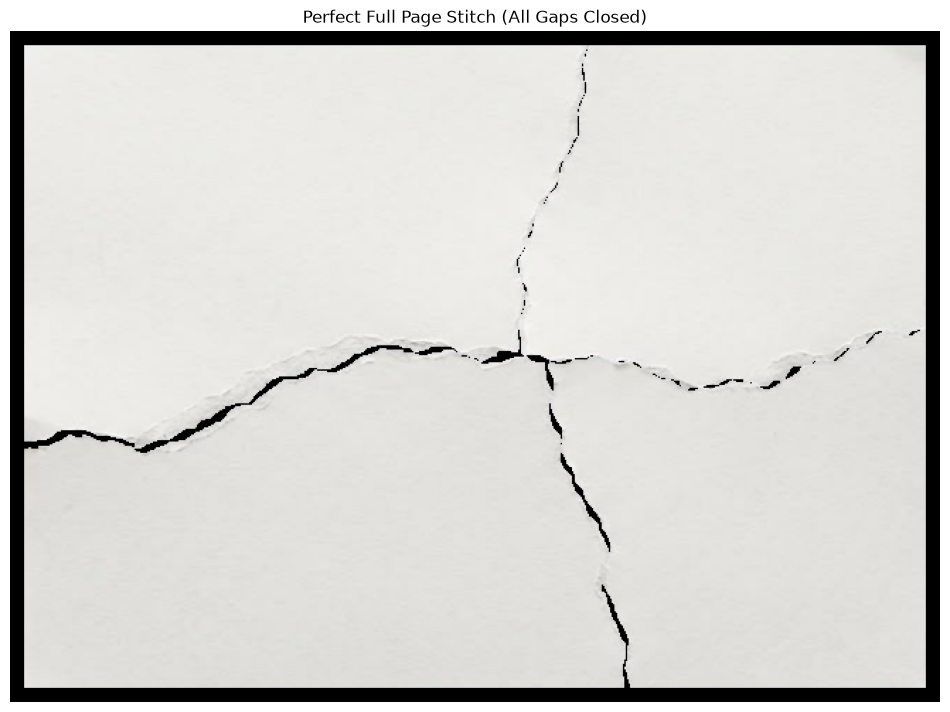

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# --- STEP 1: Generate Binary Footprint Masks ---
gray_c0 = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
_, thresh_c0 = cv2.threshold(gray_c0, 15, 255, cv2.THRESH_BINARY)

gray_c1 = cv2.cvtColor(canvas1, cv2.COLOR_BGR2GRAY)
_, thresh_c1 = cv2.threshold(gray_c1, 15, 255, cv2.THRESH_BINARY)

# --- STEP 2: Find the Robust Straight Left Edges (dx) ---
def get_robust_left_edge(thresh):
    row_mins = []
    for r in range(thresh.shape[0]):
        cols = np.where(thresh[r] == 255)[0]
        if len(cols) > 20:  # Only consider rows with valid paper pixels
            row_mins.append(cols.min())
    return int(np.median(row_mins))

left_edge_c0 = get_robust_left_edge(thresh_c0)
left_edge_c1 = get_robust_left_edge(thresh_c1)

# Horizontal shift to align the vertical left margins perfectly
dx = left_edge_c0 - left_edge_c1

# --- STEP 3: Vertical Edge Boundary Matching (dy) ---
# canvas (top piece) - bottom boundary along each column
y_pixels_c0, x_pixels_c0 = np.where(thresh_c0 == 255)
bottom_boundary_c0 = {col: np.max(y_pixels_c0[x_pixels_c0 == col]) for col in np.unique(x_pixels_c0)}

# canvas1 (bottom piece) - top boundary mapped with horizontal shift dx
y_pixels_c1, x_pixels_c1 = np.where(thresh_c1 == 255)
top_boundary_c1 = {col + dx: np.min(y_pixels_c1[x_pixels_c1 == col]) for col in np.unique(x_pixels_c1)}

# Calculate the vertical shift (dy) to lock the torn edges together
dy_offsets = [
    bottom_boundary_c0[col] - top_boundary_c1[col] + 1
    for col in bottom_boundary_c0 if col in top_boundary_c1
]
dy = int(np.percentile(dy_offsets, 90))

# --- STEP 4: Dynamic Canvas & Final Stitch ---
h0, w0 = canvas.shape[:2]
h1, w1 = canvas1.shape[:2]

min_canvas_x = min(0, dx)
max_canvas_x = max(w0, w1 + dx)
min_canvas_y = min(0, dy)
max_canvas_y = max(h0, h1 + dy)

final_width = max_canvas_x - min_canvas_x
final_height = max_canvas_y - min_canvas_y

master_canvas = np.zeros((final_height, final_width, 3), dtype=np.uint8)

offset_x0 = -min_canvas_x
offset_y0 = -min_canvas_y

offset_x1 = dx - min_canvas_x
offset_y1 = dy - min_canvas_y

# Blend pieces onto the final canvas
master_canvas[offset_y0:offset_y0+h0, offset_x0:offset_x0+w0][thresh_c0 > 0] = canvas[thresh_c0 > 0]
master_canvas[offset_y1:offset_y1+h1, offset_x1:offset_x1+w1][thresh_c1 > 0] = canvas1[thresh_c1 > 0]

# --- STEP 5: Plotting ---
plt.figure(figsize=(12, 10))
plt.title("Perfect Full Page Stitch (All Gaps Closed)")
plt.imshow(cv2.cvtColor(master_canvas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Stitching piece 2/4...
Stitching piece 3/4...
Stitching piece 4/4...


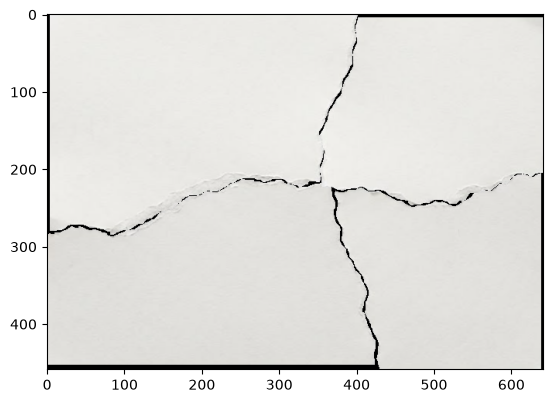

In [41]:
def ad_stitch(img_base, img_patch):
   
    m_b = (cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15).astype(np.uint8) * 255
    m_p = (cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15).astype(np.uint8) * 255
    
    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
    dist_out = cv2.distanceTransform(~m_b, cv2.DIST_L2, 5)
    dist_in = cv2.distanceTransform(m_b, cv2.DIST_L2, 5)
    
    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float('inf')
    
    for dy in range(-int(h_b * 0.8), int(h_b * 0.8)):
        for dx in range(-int(w_b * 0.8), int(w_b * 1.2)):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue
                
            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            ol_cnt = np.sum(ol)
            if ol_cnt / len(vy) > 0.35:
                continue
                
            n_vy, n_vx = vy[~ol], vx[~ol]
            if len(n_vy) == 0:
                continue
                
            gaps = dist_out[n_vy, n_vx]
            penalty = np.mean(dist_in[vy[ol], vx[ol]]) * 3.0 if ol_cnt > 0 else 0.0
            score = np.mean(gaps) + penalty - np.sum(gaps < 4.0) * 0.2
            
            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    mh, mw = max(h_b + oy, h_p + best_dy + oy), max(w_b + ox, w_p + best_dx + ox)
    
    canvas = np.zeros((mh, mw, 3), dtype=np.uint8)
    canvas[oy:oy+h_b, ox:ox+w_b] = img_base
    
    py, px = best_dy + oy, best_dx + ox
    canvas[py:py+h_p, px:px+w_p][m_p == 255] = img_patch[m_p == 255]
    return canvas

canvas = isolated_pieces_list[0]
for i in range(1, len(isolated_pieces_list)):
    print(f"Stitching piece {i + 1}/{len(isolated_pieces_list)}...")
    canvas = ad_stitch(canvas, isolated_pieces_list[i])
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.show()
